<a href="https://colab.research.google.com/github/wjdwogns2873-web/deep-learning-study/blob/main/Kaggle_Study_Practice/13_Fruit_Images_for_Object_Detection2_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 구글 드라이브 연결 (로그인 팝업이 뜨면 확인만 눌러주세요)
from google.colab import drive
drive.mount('/content/drive')

# 2. 구글 드라이브에 저장해둔 열쇠(access_token)를 코랩 보안 폴더로 자동 복사
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/Kaggle/access_token ~/.kaggle/
!chmod 600 ~/.kaggle/access_token

Mounted at /content/drive


In [1]:
!kaggle datasets download mbkinaci/fruit-images-for-object-detection

Dataset URL: https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection
License(s): CC0-1.0
100% 28.4M/28.4M [00:00<00:00, 63.9MB/s]



In [2]:
import os
import zipfile
import shutil

ZIP_PATH = './fruit-images-for-object-detection.zip'
EXTRACT_PATH = './fruit_raw' # 압축을 풀 경로?
BASE_DIR = 'dataset'

if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
        print("압축 해제 완료")
else:
    print('압축파일이 존재하지 않습니다.')

os.makedirs(os.path.join(BASE_DIR, 'train'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'test'), exist_ok=True)

압축 해제 완료


In [3]:
import glob
import torch
from PIL import Image
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset
import torchvision.transforms as T

class_to_idx = {'apple': 1, 'banana': 2, 'orange': 3}

class FruitObjectDetectionDataset(Dataset):
    def __init__(self, raw_data_dir, transforms=None):
        self.raw_data_dir = raw_data_dir
        self.transforms = transforms

        self.xml_files = sorted(glob.glob(os.path.join(raw_data_dir, '*.xml')))

    def __len__(self):
        return len(self.xml_files)

    def __getitem__(self, idx):
        xml_path = self.xml_files[idx]

        tree = ET.parse(xml_path)
        root = tree.getroot()

        img_name = root.find('filename').text
        img_path = os.path.join(self.raw_data_dir, img_name)
        img = Image.open(img_path).convert('RGB')

        boxes, labels = [], []

        for obj in root.iter('object'):
            name = obj.find('name').text
            if name not in class_to_idx:
                continue

            labels.append(class_to_idx[name])

            xmlbox = obj.find('bndbox')
            xmin = float(xmlbox.find('xmin').text)
            ymin = float(xmlbox.find('ymin').text)
            xmax = float(xmlbox.find('xmax').text)
            ymax = float(xmlbox.find('ymax').text)

            boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        image_id = torch.tensor([idx])

        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        iscrowded = torch.zeros((len(labels),), dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': image_id,
            'area': area,
            'iscrowded': iscrowded
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

In [4]:
# xml 파일 뜯어보기
raw_data_dir = './fruit_raw/train_zip/train'
xml_files = sorted(glob.glob(os.path.join(raw_data_dir, '*.xml')))

target_xml_path = xml_files[0]
print(f"원본 xml 경로: {target_xml_path}")

with open(target_xml_path, 'r', encoding='utf-8') as f:
    xml_content = f.read()

print(xml_content)

원본 xml 경로: ./fruit_raw/train_zip/train/apple_1.xml
<annotation>
	<folder>train</folder>
	<filename>apple_1.jpg</filename>
	<path>C:\tensorflow1\models\research\object_detection\images\train\apple_1.jpg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>0</width>
		<height>0</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>apple</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>8</xmin>
			<ymin>15</ymin>
			<xmax>331</xmax>
			<ymax>349</ymax>
		</bndbox>
	</object>
</annotation>



In [5]:
def conversion(image, target):
    import torchvision.transforms.functional as F
    return F.to_tensor(image), target

test_dataset = FruitObjectDetectionDataset(raw_data_dir='./fruit_raw/train_zip/train', transforms=conversion)

img_tensor, target_dto = test_dataset[11]

print(f"이미지 텐서 shape: {img_tensor.shape}")
print(f"발견된 객체 수: {len(target_dto['labels'])}개")
print(f"네모 박스 좌표들:\n{target_dto['boxes']}")
print(f"매핑된 클래스 ID들: {target_dto['labels']}")

이미지 텐서 shape: torch.Size([3, 250, 250])
발견된 객체 수: 1개
네모 박스 좌표들:
tensor([[ 37.,  52., 205., 222.]])
매핑된 클래스 ID들: tensor([1])


In [6]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_object_detection_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

NUM_CLASSES = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

my_model = get_object_detection_model(NUM_CLASSES)
my_model = my_model.to(device)

device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 127MB/s]


In [7]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = FruitObjectDetectionDataset(raw_data_dir='./fruit_raw/train_zip/train', transforms=conversion)
test_dataset = FruitObjectDetectionDataset(raw_data_dir='./fruit_raw/train_zip/train', transforms=conversion)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

params = [p for p in my_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

epochs = 3

for epoch in range(epochs):
    my_model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = my_model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item() * len(images)

    print(f"Epoch [{epoch+1}/{epochs}] - Avg Loss: {epoch_loss/len(train_loader.dataset):.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/3] - Avg Loss: 0.4142
Epoch [2/3] - Avg Loss: 0.2080
Epoch [3/3] - Avg Loss: 0.1721


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_prediction(dataset, model, device, index=0):
    model.eval()

    image, target = dataset[index]

    with torch.no_grad():
        prediction = model([image.to(device)])
        print(type(prediction))

    np_image = image.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(np_image)

    pred_boxes = prediction[0]['boxes'].cpu().numpy()
    pred_labels = prediction[0]['labels'].cpu().numpy()
    pred_scores = prediction[0]['scores'].cpu().numpy()

    idx_to_class = {1: 'apple', 2: 'banana', 3: 'orange'}

    detected_count = 0
    for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
        if score > 0.5:
            detected_count += 1
            xmin, ymin, xmax, ymax = box

            width = xmax - xmin
            height = ymax - ymin

            rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

            class_name = idx_to_class.get(label, 'unknown')
            plt.text(xmin, ymin - 10, f"{class_name} {score:.2f}", color='white',
                     verticalalignment='top', bbox={'boxstyle': 'square', 'facecolor': 'red', 'alpha': 0.5})

    plt.axis('off')
    plt.title(f"AI Detection Result (Found: {detected_count} objects)")
    plt.show()

<class 'list'>


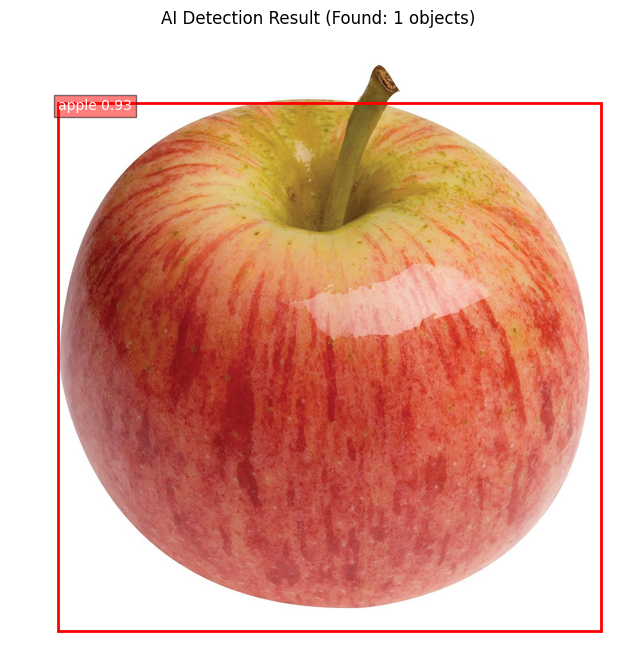

In [12]:
visualize_prediction(test_dataset, my_model, device, index=1)

In [13]:
sample_image, _ = test_dataset[0]

my_model.eval()
with torch.no_grad():
    sample_prediction = my_model([sample_image.to(device)])

print(f"Type: {type(sample_prediction)} (길이: {len(sample_prediction)})")

for key, value in sample_prediction[0].items():
    print(f"\nKey[{key}] (Shape: {value.shape})")
    print(value)

Type: <class 'list'> (길이: 1)

Key[boxes] (Shape: torch.Size([1, 4]))
tensor([[ 16.2053,  61.0491, 314.2832, 347.6596]], device='cuda:0')

Key[labels] (Shape: torch.Size([1]))
tensor([1], device='cuda:0')

Key[scores] (Shape: torch.Size([1]))
tensor([0.9881], device='cuda:0')
